In [1]:
import numpy as np
# from PIL import Image
import taichi as ti
# import taichi_volume_renderer as tvr
import matplotlib.pyplot as plt

ti.init(arch=ti.gpu)

[Taichi] version 1.7.3, llvm 15.0.1, commit 5ec301be, win, python 3.12.3
[Taichi] Starting on arch=cuda


# 用单个文件测试网格转化

In [22]:
real_size = 40  # 实物边长（mm）

实物圆角 = 4.8


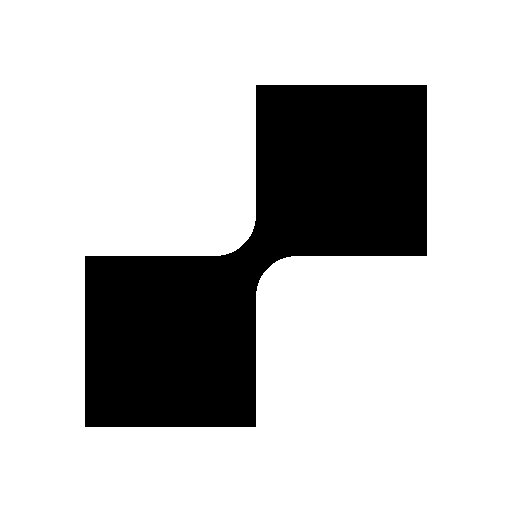

In [ ]:
from utils import test_forbidden_function
from PIL import Image

radius = 0.12  # 给中间加一个圆角，不然沙发必然不是连通的
print('实物圆角 =', radius * real_size)
@ti.func
def is_forbidden_2d(y, z):
    return (y < -radius and z > 0. or y < 0. and z > radius or (y + radius) ** 2 + (z - radius) ** 2 < radius ** 2) or (y > radius and z < 0. or y > 0. and z < -radius or (y - radius) ** 2 + (z + radius) ** 2 < radius ** 2) or abs(y) > 0.5 or abs(z) > 0.5  # 两个正方形的孔，中间少阻挡一部分区域以让沙发连通

image = test_forbidden_function(
    is_forbidden_2d,
    -0.75, 0.75, -0.75, 0.75,
)
Image.fromarray(np.array(image.T[::-1] * 255, dtype=np.uint8))

In [ ]:
(2 ** 0.5 - 1) * radius * 2 * real_size  # 连接处实际宽度，方块边长为40mm

2.6509667991878088

实物适配的板厚 = 1.6


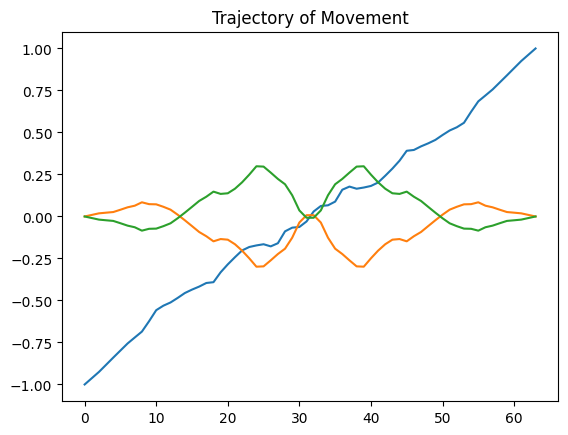

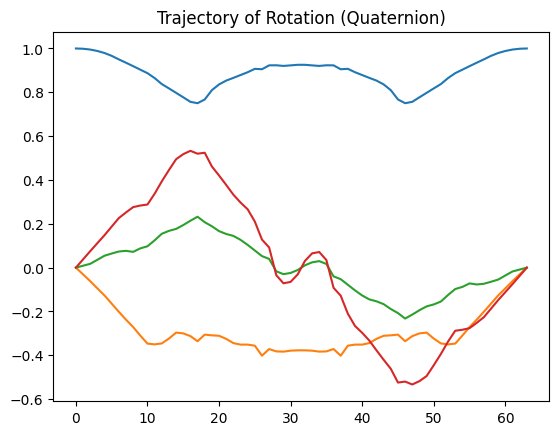

In [ ]:
sofa_w = 1  # 求解域的尺寸
sofa_h = 1
sofa_d = 1

# @ti.func
# def is_forbidden_1(x0, y0, z0, x1, y1, z1):  # 指定哪里是墙
#     return ((x0 > 0.) ^ (x1 > 0.)) and is_forbidden_2d(y1, z1)  # 两个正方形的孔

thickness = 0.04  # 墙的厚度，如果过小，打印出来的物体会难以穿过有实际厚度的墙上的洞
print('实物适配的板厚 =', thickness * real_size)

@ti.func
def is_forbidden_2(x0, y0, z0, x1, y1, z1):  # 指定哪里是墙（有厚度的墙，有厚度是为了避免展示视频中出现明显的穿模）
    return (((x0 > 0.) ^ (x1 > 0.)) or abs(x1) < thickness * 0.5) and is_forbidden_2d(y1, z1)  # 两个正方形的孔

trajectory = np.load('../trajectory/穿过两个正方形孔_17/sofa_800.npy')
xs = trajectory[:, 0]
ys = trajectory[:, 1]
zs = trajectory[:, 2]
rotations = trajectory[:, 3:]

len(xs)

plt.plot(xs, markersize=2)
plt.plot(ys, markersize=2)
plt.plot(zs, markersize=2)
plt.title('Trajectory of Movement')
plt.show()

plt.plot(rotations[:, 0], markersize=2)
plt.plot(rotations[:, 1], markersize=2)
plt.plot(rotations[:, 2], markersize=2)
plt.plot(rotations[:, 3], markersize=2)
plt.title('Trajectory of Rotation (Quaternion)')
plt.show()


In [19]:
from utils import get_sofa_3d

sofa = get_sofa_3d(is_forbidden_2, xs, ys, zs, rotations, sofa_w=sofa_w, sofa_h=sofa_h, sofa_d=sofa_d, resolution=512, trajectory_upsampling=201)

sofa.shape

(512, 512, 512)

In [20]:
from tooppy.mesh import convert_to_mesh, plot_mesh, save_mesh

# Assume you runed test_3d.py firsly, resulting in a NumPy array file result_3d.npy at ./output/.
# Now we load it, convert it to a mesh and then save it as an STL file.

mesh = convert_to_mesh(sofa, iso=0.5, sharpen_strength=0.6, smoothen_radius=2.5, upsample_factor=1)
plot_mesh(mesh)

In [21]:
save_mesh(mesh, f'../meshes/穿过两个正方形孔_17/800_for_3d_printing_radius{radius}_thickness{thickness}.stl')